In [2]:
import pandas as pd 
import  numpy as np

courses = pd.read_csv(r"C:\Users\Asus\Downloads\courses.csv")
students = pd.read_csv(r"C:\Users\Asus\Downloads\students.csv")
nov = pd.read_csv(r"C:\Users\Asus\Downloads\reg-month1.csv")
dec = pd.read_csv(r"C:\Users\Asus\Downloads\reg-month2.csv")

matches = pd.read_csv(r"C:\Users\Asus\Downloads\matches.csv")
delivery = pd.read_csv(r"C:\Users\Asus\Downloads\deliveries.csv")

In [3]:
#Agar do data ko kabhi vertically stack karne ki zarurat pade to i can use pd.concat()

#For example nov ke registration and dec ke registrations together comprise total registrations therefore :-

pd.concat([nov,dec]) #Kitnne bhi jod skte hai 

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [4]:
#Ab dhyaan se dekh upar ki nov ke registrations ka index 24 tak haoi and dec ka 27 tak par merge karne ke  baad index is retained respectively by both of the, continuous increment nhi hua and kuch cases main yeh shi nhi hai to we use ignore_index paramater 

regs=pd.concat([nov,dec],ignore_index=True) #Ab retain nhi hoga 


In [5]:
#now what if jo ignore_index kiya maine uski jagah main yeh intetnally self generated index ko back main to rkhu hi saath hi differentiation create karne ke liye purane bhi rehne du ?
multi=pd.concat([nov,dec],keys=["NOV","DEC"])  #yni nov ke pass NOV index and dec ke pass DEC index 

#THis is called multiindex dataframe


In [6]:
#HOw to work with multiindex dataframe 
multi.loc["DEC"]

,student_id,course_id
0,3,5
1,16,7
2,12,10
3,12,1
4,14,9
5,7,7
6,7,2
7,16,3
8,17,10
9,11,8


In [7]:
#NOV ke andar 0  chahiye 
multi.loc[("NOV",0)]

student_id    23
course_id      1
Name: (NOV, 0), dtype: int64

In [8]:
#Horizontal concatenation
pd.concat([nov,dec],axis=1)

#But why 28 rows bro ? because horizontal stacking ke time jo dataframe main max rows hoi resulting frame ka no of rows bhi utna hi higa and jo chota frame hai uski remaining rows NaN se bhar jayengi 

,student_id,course_id,student_id,course_id
0,23.0,1.0,3,5
1,15.0,5.0,16,7
2,18.0,6.0,12,10
3,23.0,4.0,12,1
4,16.0,9.0,14,9
5,18.0,1.0,7,7
6,1.0,1.0,7,2
7,7.0,8.0,16,3
8,22.0,3.0,17,10
9,15.0,1.0,11,8


In [9]:
#Merging the DataFrames
#Joining based on logical conditions 

#Do dataframes ko join karna based on a common column 
#Requirement ?:-manlo  ek student dataframe hai jahan info hai regarding students  and then regs datafframe hai containing jahan nov and dec ke registation jod ke saare dataframe banaye. 

#Ab manager ne ye data dekha usne dekha ohh student id =23 ne course number course id 1 mainn enroll kiya ab manager bol rah ki students ka naam bhi laa do  to kaisse laoge either you will add a new column name students or you  will merge both students dataframe and regs dataframe coz both contains the student_id
 
# Visual representation:-




Merge dataframes explained · MD
# Merging DataFrames on SID — Student + Reg 🔗
 
## 1. Sabse pehle — kya cheez hai kya
 
Do dataframes hain:
 
- **`student` df** → columns: `sid`, `name`
- **`reg` df** → columns: `sid`, `cid`
Goal: In dono ko `sid` ke basis pe merge karke ek naya dataframe banana jisme **teen columns** hon — `sid`, `name`, `cid`.
 
```mermaid
graph LR
    subgraph STUDENT["🎓 student df"]
        S1[sid]
        S2[name]
    end
    subgraph REG["📚 reg df"]
        R1[sid]
        R2[cid]
    end
    S1 <-->|"common key"| R1
 
    classDef studentStyle fill:#4A90D9,stroke:#1B4F91,stroke-width:2px,color:#ffffff
    classDef regStyle fill:#F5A623,stroke:#B5760F,stroke-width:2px,color:#000000
    class S1,S2 studentStyle
    class R1,R2 regStyle
```
 
`sid` dono dataframes me common column hai — yahi ye "bridge" hai jo dono ko jodega.
 
---
 
## 2. Merge kaise hota hai (logic, step-by-step)
 
Yaha pe important baat: **loop `reg` df pe chalta hai**, `student` pe nahi. Kyun? Kyunki `reg` me already `sid` aur `cid` dono seedhe available hain — sirf `name` missing hai, aur wo `student` se laana padega.
 
Har row ke liye:
 
1. `reg` se current row ka `sid` aur `cid` uthao → seedhe naye row me daal do.
2. Ab `name` ke liye `student` df me jaake usi `sid` ko dhundo.
3. Agar match mil gaya → uska `name` utha ke naye row me daal do.
4. Agar match **nahi** mila (yaani wo `sid` `student` df me exist hi nahi karta) → `name` ki jagah **`NaN`** pad jaayega.
5. Yehi process **har row** ke liye repeat hota hai jab tak `reg` df khatam na ho jaaye.
```mermaid
flowchart TD
    A(["Start: reg df pe row-by-row loop"]) --> B["Current row se sid aur cid uthao"]
    B --> C["sid aur cid seedhe naye result-row me copy karo"]
    C --> D{"Yeh sid student df<br/>me search karo"}
    D -->|Match mil gaya| E["Matching row ka name utha lo"]
    D -->|Match nahi mila| F["name = NaN set karo"]
    E --> G["name ko result-row me add karo"]
    F --> G
    G --> H{"reg me aur<br/>rows bache hain?"}
    H -->|Haan| B
    H -->|Nahi| I(["End: Final merged df — sid, name, cid"])
 
    classDef startEnd fill:#6BCB77,stroke:#2E7D32,stroke-width:2px,color:#000000
    classDef process fill:#4D96FF,stroke:#1B4F91,stroke-width:2px,color:#ffffff
    classDef decision fill:#FFD93D,stroke:#B8860B,stroke-width:2px,color:#000000
    classDef fail fill:#FF6B6B,stroke:#C62828,stroke-width:2px,color:#ffffff
    class A,I startEnd
    class B,C,E,G process
    class D,H decision
    class F fail
```
 
---
 
## 3. Example ke saath dekhte hain (real numbers)
 
**student df:**
 
| sid | name   |
|-----|--------|
| 1   | Nikhil |
| 2   | Amit   |
| 3   | Rahul  |
 
**reg df:**
 
| sid | cid |
|-----|-----|
| 1   | 7   |
| 2   | 5   |
| 6   | 8   |
 
Ab dhyan do — `reg` df me ek row hai jiska `sid = 6`, but `student` df me `sid = 6` **exist hi nahi karta** (student me sirf 1, 2, 3 hain). Yehi wo case hai jaha `NaN` aayega.
 
```mermaid
graph TD
    subgraph RESULT["✅ Final Merged df"]
        direction TB
        Row1["sid = 1 | name = Nikhil | cid = 7"]
        Row2["sid = 2 | name = Amit | cid = 5"]
        Row3["sid = 6 | name = NaN | cid = 8"]
    end
 
    classDef matched fill:#6BCB77,stroke:#2E7D32,stroke-width:2px,color:#000000
    classDef unmatched fill:#FF6B6B,stroke:#C62828,stroke-width:2px,color:#ffffff
    class Row1,Row2 matched
    class Row3 unmatched
```
 
**Final result table:**
 
| sid | name   | cid |
|-----|--------|-----|
| 1   | Nikhil | 7   |
| 2   | Amit   | 5   |
| 6   | NaN    | 8   |
 
---
 
## 4. Ek line me yaad rakhne wali baat
 
> Loop **join-column wali table** (`reg`) pe chalta hai. Jo direct available hai (`sid`, `cid`) wo seedha copy hota hai. Jo dusri table se laana hai (`name`) uske liye `sid` match dhunda jaata hai — match mila to value aayegi, nahi mila to **`NaN`**.
 
*(Bonus: Pandas me yehi kaam ek line me ho jaata hai — `pd.merge(reg, student, on='sid', how='left')`.)*
 


In [10]:
#Inner join  kehte hai is upar wali technique ko plus one more thing jab inner join karna ho to do frames rahenge un dono main koii common cheez dhundege jisse ki join ho sake

In [11]:
#Students main 25 students and regs main 53 registrations hai matlab courses 53 baaar kharide gaye ab in dono pe inner join hoga ab hoga to ek column common hoga jiske  basis pe hoga and since inner join therefore sirf whi dikhenge students jo dono main commmon hain 

#inner join
students.merge(regs,how="inner",on="student_id")

#Students banega left column regs banega right how parameter batayega ki kounsa join karna hai (inner,outer,full etc ) and on batayega kis column ke basis  pe karna hai 

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,10
3,1,Kailash Harjo,23,9
4,2,Esha Butala,1,5
5,3,Parveen Bhalla,3,3
6,3,Parveen Bhalla,3,5
7,7,Tarun Thaker,9,8
8,7,Tarun Thaker,9,10
9,7,Tarun Thaker,9,7


In [12]:
#Aakhri student id dekho 25 aayegi therefore mostly data nhi aaya since inner join 

In [13]:
#Left join:- funda same hai  par common cheez har frame ki include to hogi hi hogi par left frame ki woh cheezein bhi include hogi jo right main nhi hai 
 #Ab courses frame mian numpy and cpp(c++) karke course hai jinka something kuch course id hai par agar regs mainn jau to kisine in courses ke liye register hi nhi kiya .Seee what will happen if you perform a left join since both frames main course_id is common 

In [14]:
courses.merge(regs,how="left",on="course_id")

# see? numpy cpp aaye frame main par since no students registered therefore student id  =nan

,course_id,course_name,price,student_id
0,1,python,2499,23.0
1,1,python,2499,18.0
2,1,python,2499,1.0
3,1,python,2499,15.0
4,1,python,2499,21.0
5,1,python,2499,25.0
6,1,python,2499,12.0
7,1,python,2499,14.0
8,1,python,2499,38.0
9,2,sql,3499,19.0


In [15]:
temp_df=pd.DataFrame({
    "student_id":[26,27,28],
    "name":["Nitish","Ankit","Rahul"],
    "partner":[28,26,17]
})

students=pd.concat([students,temp_df],ignore_index=True)

In [16]:
students.merge(regs,how="right",on="student_id")

#RIght join is just  opposite  on left join left join main common data ke saath left ka pura data dikhta tha irrespective of the fact that they are in right or not 

#SImilarly right join mai common ke saath saath right ka bhi pura data dikhega irrespective of whether its in leeft or not    

,student_id,name,partner,course_id
0,23,Chhavi Lachman,18.0,1
1,15,Preet Sha,16.0,5
2,18,Fardeen Mahabir,13.0,6
3,23,Chhavi Lachman,18.0,4
4,16,Elias Dodiya,25.0,9
5,18,Fardeen Mahabir,13.0,1
6,1,Kailash Harjo,23.0,1
7,7,Tarun Thaker,9.0,8
8,22,Yash Sethi,21.0,3
9,15,Preet Sha,16.0,1


In [17]:
# full join/outer joinn main sabka data  aayega common +left ka +right ka bhi 

students.merge(regs,how="outer",on="student_id")

,student_id,name,partner,course_id
0,1,Kailash Harjo,23.0,1.0
1,1,Kailash Harjo,23.0,6.0
2,1,Kailash Harjo,23.0,10.0
3,1,Kailash Harjo,23.0,9.0
4,2,Esha Butala,1.0,5.0
...,...,...,...,...
58,27,Ankit,26.0,NaN
59,28,Rahul,17.0,NaN
60,38,NaN,NaN,1.0
61,42,NaN,NaN,9.0


In [18]:
#Find total revenue generated 
#99% tumko inner joinnn hi use karna padega 

#to solve this  ab course kounse hai kitne hai kisne liye and and fees chahiye  hogi to courses and registration ke beech join 

courses.merge(regs,how="inner",on="course_id")["price"].sum()

np.int64(154247)

In [19]:
#Find month by month revenue  yni nov and dec mainn kitne registration hue and dono moths main kitna revenue hua ?

temp_df=pd.concat([nov,dec],keys=["Nov","Dec"]).reset_index()
#this will first give me a multiindex dataframe jisme nov and dec wise data rahega then reset_index usko ek normal dataframe bana deta hai jiski mujhe actually zarurat hai


temp_df.merge(courses,on="course_id").groupby("level_0")["price"].sum()

level_0
Dec    65072
Nov    89175
Name: price, dtype: int64

In [20]:
#Print a registration table containing names of students courses and their price 
#  ab is  table ke liye teen table lagenge students and courses is in regs , courses and their fee is in courses table ,and students name is in students table 

total=regs.merge(students,on="student_id").merge(courses,on="course_id")
total[["name","course_name","price"]]

,name,course_name,price
0,Chhavi Lachman,python,2499
1,Preet Sha,tableau,2499
2,Fardeen Mahabir,power bi,1899
3,Chhavi Lachman,machine learning,9999
4,Elias Dodiya,plotly,699
5,Fardeen Mahabir,python,2499
6,Kailash Harjo,python,2499
7,Tarun Thaker,pandas,1099
8,Yash Sethi,data analysis,4999
9,Preet Sha,python,2499


<Axes: xlabel='course_name'>

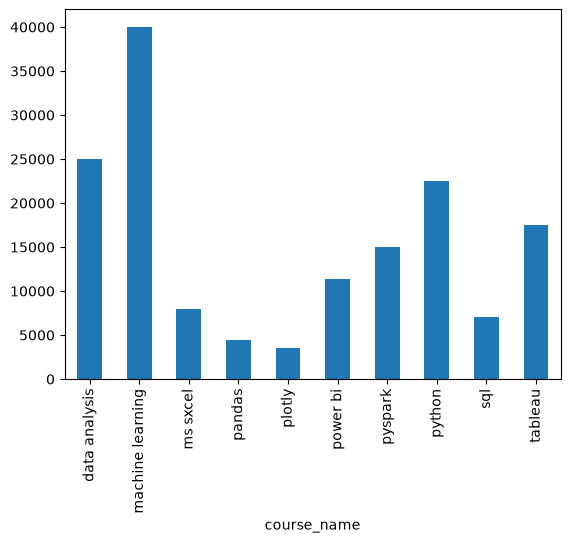

In [21]:
#PLot a bar chart shoeing information regarding revenue  per course 
bar_chart=regs.merge(courses,on="course_id").groupby("course_name")["price"].sum()

bar_chart.plot(kind="bar")

In [22]:
#Find students who enrolled in both months yni 2 mahine main 
#NOvember and december main apply karte hue studetnts ki id nikal lo and them unke beech ka intersection nikal lo 

common_student_id=np.intersect1d(nov["student_id"],dec["student_id"])

students[students["student_id"].isin([ 1,  3,  7, 11, 16, 17, 18, 22, 23])]

,student_id,name,partner
0,1,Kailash Harjo,23
2,3,Parveen Bhalla,3
6,7,Tarun Thaker,9
10,11,David Mukhopadhyay,20
15,16,Elias Dodiya,25
16,17,Yasmin Palan,7
17,18,Fardeen Mahabir,13
21,22,Yash Sethi,21
22,23,Chhavi Lachman,18


In [23]:
# find course that got no enrollment
temp_df=courses.merge(regs,how="left",on="course_id")
temp_df[temp_df["student_id"].isna()]


,course_id,course_name,price,student_id
53,11,Numpy,699,NaN
54,12,C++,1299,NaN


In [24]:
#Students who havent enrolled inn any courses 
temp_df1=students.merge(regs,how="left",on="student_id")
temp_df1[temp_df1["course_id"].isna()]
students

,student_id,name,partner
0,1,Kailash Harjo,23
1,2,Esha Butala,1
2,3,Parveen Bhalla,3
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6
5,6,Lakshmi Contractor,10
6,7,Tarun Thaker,9
7,8,Radheshyam Dey,5
8,9,Nitika Chatterjee,4
9,10,Aayushman Sant,8


In [26]:
#PRint student name and partname name for all enrolled students
#EK new kind of join known as self join jisme ek table ko khud se hi join karunga koi do columns ke basis pe ?

students.merge(students,how="inner",left_on="partner",right_on="student_id")[["name_x","name_y"]]



,name_x,name_y
0,Kailash Harjo,Chhavi Lachman
1,Esha Butala,Kailash Harjo
2,Parveen Bhalla,Parveen Bhalla
3,Marlo Dugal,Pranab Natarajan
4,Kusum Bahri,Lakshmi Contractor
5,Lakshmi Contractor,Aayushman Sant
6,Tarun Thaker,Nitika Chatterjee
7,Radheshyam Dey,Kusum Bahri
8,Nitika Chatterjee,Marlo Dugal
9,Aayushman Sant,Radheshyam Dey


In [34]:
#Students jinhon courses main sabse zyada enroll kiya hai 
regs.merge(students,on="student_id")["name"].value_counts()

#THis is wrong because agar yeh kiya  toh do similar naam with diffferent ourses gets same coutn hence group by is used 

regs.merge(students,on="student_id").groupby(["name","student_id"])["name"].count().sort_values(ascending=False)

name                student_id
Chhavi Lachman      23            6
Tarun Thaker        7             5
Radha Dutt          12            4
Elias Dodiya        16            4
Pranab Natarajan    14            4
Kailash Harjo       1             4
David Mukhopadhyay  11            3
Yash Sethi          22            3
Fardeen Mahabir     18            3
Preet Sha           15            2
Shashank D’Alia     25            2
Yasmin Palan        17            2
Parveen Bhalla      3             2
Qabeel Raman        19            2
Munni Varghese      13            1
Esha Butala         2             1
Seema Kota          21            1
Radhika Suri        24            1
Name: name, dtype: int64

In [40]:
#FInd top 3 students who spent most amoutnt of money on courses 
students.merge(regs,on="student_id").merge(courses,on="course_id").groupby("name")["price"].sum().sort_values(ascending=False).head(3)

name
Chhavi Lachman      22594
Pranab Natarajan    15096
Qabeel Raman        13498
Name: price, dtype: int64

In [ ]:
#Find top 3 stadiums with highest sixes/match ratio  